# 📋 Module M6 — Prédiction du Churn Client
### Projet `marketing.optimization` — Person 5 (Predictive Data Scientist)

**Objectif :** construire un modèle de Machine Learning qui prédit la probabilité
qu'un client cesse d'acheter (churn), afin de fournir à l'équipe marketing
(Person 6) un score de risque par client.

**Option choisie : A — Prédiction du Churn** (classification binaire), recommandée
car l'historique temporel disponible (`Date` dans `sales_clean.csv`) est limité à
une période d'observation unique plutôt qu'à plusieurs cycles d'achat futurs — un
contexte pour lequel la classification churn est plus robuste que la régression CLV.

**Entrées :**
- `data/processed/customers_clean.csv` (Person 1)
- `data/processed/sales_clean.csv` (Person 1)
- `data/processed/customer_segments.csv` (Person 2, optionnel)

**Sortie (contrat) :**
- `data/processed/churn_clv_predictions.csv` → `Customer_ID, Cluster, Churn_Probability, Churn_Prediction, Risk_Segment`
- `notebooks/model_churn_or_clv.pkl` (modèle entraîné, sérialisé avec `joblib`)

---


## 1. Setup & imports

In [19]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠️ xgboost not installed — run: pip install xgboost")

import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load data

Paths are relative to the repo root (`marketing.optimization/`), matching the
project's shared folder structure. Run this notebook from `notebooks/` with the
repo root as the working directory, or adjust `DATA_DIR` below.

In [20]:
DATA_DIR = "../data/processed"   # adjust if running from a different working dir
MODEL_OUT = "../models/model_churn_or_clv.pkl"
PRED_OUT = os.path.join(DATA_DIR, "churn_clv_predictions.csv")

customers = pd.read_csv(os.path.join(DATA_DIR, "customers_clean.csv"))
sales = pd.read_csv(os.path.join(DATA_DIR, "sales_clean.csv"))

# Optional: Person 2's cluster labels (only Customer_ID + Cluster are kept — the rest of
# that file may re-derive Age/Total_Spent/etc. and would collide with our own columns)
segments_path = os.path.join(DATA_DIR, "customer_segments.csv")
has_segments = os.path.exists(segments_path)
if has_segments:
    segments = pd.read_csv(segments_path)
    segments['Customer_ID'] = segments['Customer_ID'].astype(str)   # match dtype below
    print(f"✅ customer_segments.csv found — {segments.shape[0]} rows, will be used as a feature.")
else:
    segments = None
    print("⚠️ customer_segments.csv not found — proceeding without cluster feature (optional per spec).")

# Optional: Person 1's products_clean.csv, used to derive each customer's favorite category
products_path = os.path.join(DATA_DIR, "products_clean.csv")
has_products = os.path.exists(products_path)
if has_products:
    products = pd.read_csv(products_path)
    print(f"✅ products_clean.csv found — {products.shape[0]} rows, will be used to derive favorite category.")
else:
    products = None
    print("⚠️ products_clean.csv not found — 'favorite category' feature will be skipped.")

print("\ncustomers_clean.csv:", customers.shape)
print("sales_clean.csv:", sales.shape)
customers.head()


✅ customer_segments.csv found — 4 rows, will be used as a feature.
✅ products_clean.csv found — 5 rows, will be used to derive favorite category.

customers_clean.csv: (5, 7)
sales_clean.csv: (5, 8)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


In [21]:
sales.head()

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Total_Amount
0,1,101,2001,2023-01-15,2,50.0,Online,100.0
1,2,102,2002,2023-01-16,1,75.0,In-Store,75.0
2,3,103,2001,2023-01-17,3,30.0,Online,90.0
3,4,104,2003,2023-01-18,1,120.0,In-Store,120.0
4,5,105,2004,2023-01-19,2,45.0,Online,90.0


In [22]:
# Basic sanity checks + dtype alignment
# Customer_ID may be read as int64 in one file and str in another (e.g. after upstream
# cleaning steps) — cast everything to str up front so every merge below matches reliably.
customers['Customer_ID'] = customers['Customer_ID'].astype(str)
sales['Customer_ID'] = sales['Customer_ID'].astype(str)
customers['Join_Date'] = pd.to_datetime(customers['Join_Date'], errors='coerce')
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
if has_products:
    products['Product_ID'] = products['Product_ID'].astype(str)
    sales['Product_ID'] = sales['Product_ID'].astype(str)

print("Missing values — customers:")
print(customers.isna().sum())
print("\nMissing values — sales:")
print(sales.isna().sum())

# ⚠️ Sanity check on sample size — this pipeline (train/test split, cross-validation,
# 3-model comparison, AUC-ROC) needs a reasonably sized customer base to produce
# meaningful results. A handful of customers is enough to prove the pipeline *runs*
# end-to-end, but any metrics on that few rows are not statistically meaningful.
N_CUSTOMERS = customers['Customer_ID'].nunique()
print(f"\nUnique customers: {N_CUSTOMERS}")
if N_CUSTOMERS < 30:
    print(f"⚠️ Only {N_CUSTOMERS} customers found in customers_clean.csv. This looks like a "
          f"small demo/stub dataset rather than the full dataset. The notebook below is "
          f"written to run end-to-end regardless of size (with small-sample fallbacks for "
          f"the split, cross-validation, and metrics), but treat any results as illustrative "
          f"only until this is re-run on the real, full-sized customer base.")


Missing values — customers:
Customer_ID    0
Name           0
Age            0
Gender         0
Location       0
Join_Date      0
Total_Spent    0
dtype: int64

Missing values — sales:
Sale_ID         0
Product_ID      0
Customer_ID     0
Date            0
Quantity        0
Sale_Price      0
Channel         0
Total_Amount    0
dtype: int64

Unique customers: 5
⚠️ Only 5 customers found in customers_clean.csv. This looks like a small demo/stub dataset rather than the full dataset. The notebook below is written to run end-to-end regardless of size (with small-sample fallbacks for the split, cross-validation, and metrics), but treat any results as illustrative only until this is re-run on the real, full-sized customer base.


## 3. Build the per-customer feature table

We aggregate `sales_clean.csv` to the customer level and join it with
`customers_clean.csv` (and `customer_segments.csv` if available).

In [23]:
# Reference date = most recent transaction in the dataset (proxy for "today")
REFERENCE_DATE = sales['Date'].max()
print("Reference date used for recency calculations:", REFERENCE_DATE.date())

sales_agg = sales.groupby('Customer_ID').agg(
    Nb_Purchases=('Sale_ID', 'count'),
    Total_Amount_Sum=('Total_Amount', 'sum'),
    Avg_Basket=('Total_Amount', 'mean'),
    Last_Purchase_Date=('Date', 'max'),
    First_Purchase_Date=('Date', 'min'),
).reset_index()

sales_agg['Recency_days'] = (REFERENCE_DATE - sales_agg['Last_Purchase_Date']).dt.days

# Favorite channel per customer (encoded later as a category)
fav_channel = (
    sales.groupby(['Customer_ID', 'Channel']).size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('Customer_ID')[['Customer_ID', 'Channel']]
    .rename(columns={'Channel': 'Favorite_Channel'})
)
sales_agg = sales_agg.merge(fav_channel, on='Customer_ID', how='left')

# Favorite product category per customer (spec asks for "favorite categories, encoded")
# Requires joining sales -> products on Product_ID, so only computed if products_clean.csv is available.
if has_products and 'Category' in products.columns:
    sales_with_cat = sales.merge(products[['Product_ID', 'Category']], on='Product_ID', how='left')
    fav_category = (
        sales_with_cat.groupby(['Customer_ID', 'Category']).size()
        .reset_index(name='n')
        .sort_values('n', ascending=False)
        .drop_duplicates('Customer_ID')[['Customer_ID', 'Category']]
        .rename(columns={'Category': 'Favorite_Category'})
    )
    sales_agg = sales_agg.merge(fav_category, on='Customer_ID', how='left')

features = customers.merge(sales_agg, on='Customer_ID', how='left')

if has_segments:
    seg_cols = ['Customer_ID'] + [c for c in ['Cluster'] if c in segments.columns]
    features = features.merge(segments[seg_cols], on='Customer_ID', how='left')

# --- Tenure_days: use it if Person 1 already computed it; otherwise derive it ourselves
# from Join_Date. This makes the notebook resilient to differences in Person 1's exact
# column set, since the spec's column list is a target, not a guarantee.
if 'Tenure_days' not in features.columns:
    if 'Join_Date' in features.columns:
        features['Tenure_days'] = (REFERENCE_DATE - features['Join_Date']).dt.days
        print("⚠️ 'Tenure_days' not found in customers_clean.csv — computed from Join_Date instead.")
    else:
        features['Tenure_days'] = features['Recency_days'].fillna(0)
        print("⚠️ Neither 'Tenure_days' nor 'Join_Date' found — using Recency_days as a rough fallback.")

# Customers present in customers_clean.csv but with zero sales (edge case)
features['Nb_Purchases'] = features['Nb_Purchases'].fillna(0)
features['Total_Amount_Sum'] = features['Total_Amount_Sum'].fillna(0)
features['Avg_Basket'] = features['Avg_Basket'].fillna(0)
features['Recency_days'] = features['Recency_days'].fillna(features['Tenure_days'])

print(features.shape)
features.head()


Reference date used for recency calculations: 2023-01-19
⚠️ 'Tenure_days' not found in customers_clean.csv — computed from Join_Date instead.
(5, 17)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Nb_Purchases,Total_Amount_Sum,Avg_Basket,Last_Purchase_Date,First_Purchase_Date,Recency_days,Favorite_Channel,Favorite_Category,Cluster,Tenure_days
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2.0,190.0,95.0,2023-01-17,2023-01-15,2.0,Online,Clothing,2.0,254
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1.0,75.0,75.0,2023-01-16,2023-01-16,3.0,In-Store,Clothing,0.0,218
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1.0,120.0,120.0,2023-01-18,2023-01-18,1.0,In-Store,Outerwear,1.0,183
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1.0,90.0,90.0,2023-01-19,2023-01-19,0.0,Online,Accessories,0.0,147
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0,0.0,0.0,0.0,NaT,NaT,111.0,NaN,NaN,NaN,111


## 4. Define the churn target variable

`sales_clean.csv` has no explicit `Churn` column — it must be **constructed**
from purchasing behavior. We document two candidate rules and pick one; the
choice is a key point to defend orally.

**Rule chosen: Recency-based churn.**
A customer is labeled **churned (1)** if their `Recency_days` (days since their
last purchase, relative to the most recent date observed in the dataset)
exceeds a threshold `X`, derived from the distribution of purchase recency.

We set `X` at the **75th percentile of `Recency_days`** across all customers —
i.e. a customer who hasn't bought in longer than 75% of the customer base is
flagged at risk. This is more principled than an arbitrary fixed number of days,
and adapts automatically to this dataset's actual purchase cadence.

**Fallback rule (documented, not used unless recency data is too sparse):**
`churn = 1` if `Nb_Purchases == 1` (one-time buyer who never returned), else `0`.
This alternative is simpler but less informative — it ignores *when* the single
purchase happened, and treats a customer who bought once yesterday the same as
one who bought once two years ago.

We keep the fallback rule computed as `Churn_singlepurchase` for comparison /
sensitivity-analysis purposes, but train on the recency-based rule.

Recency threshold (75th percentile): 3 days
Churn rate (recency-based rule): 20.0%
Churn rate (single-purchase rule, for reference): 80.0%


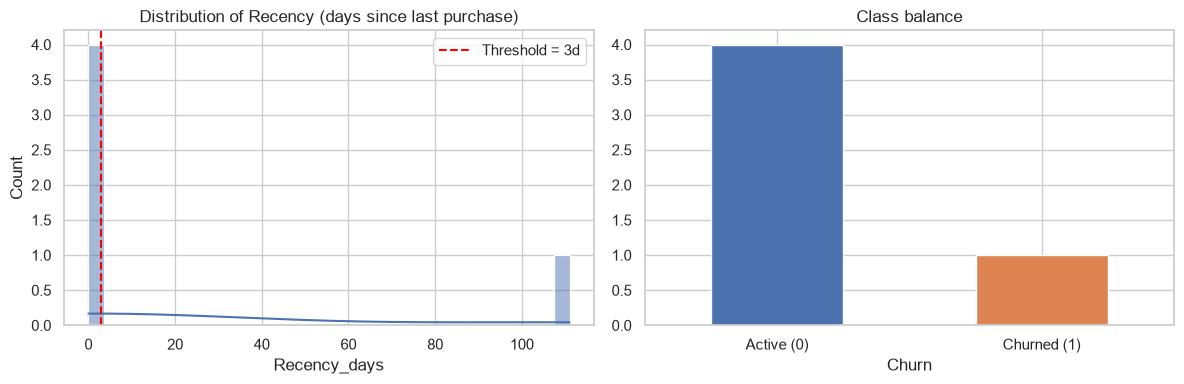

In [24]:
RECENCY_THRESHOLD = features['Recency_days'].quantile(0.75)
print(f"Recency threshold (75th percentile): {RECENCY_THRESHOLD:.0f} days")

features['Churn'] = (features['Recency_days'] > RECENCY_THRESHOLD).astype(int)

# Fallback rule, kept for comparison only
features['Churn_singlepurchase'] = (features['Nb_Purchases'] <= 1).astype(int)

churn_rate = features['Churn'].mean()
print(f"Churn rate (recency-based rule): {churn_rate:.1%}")
print(f"Churn rate (single-purchase rule, for reference): {features['Churn_singlepurchase'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(features['Recency_days'], bins=30, ax=axes[0], kde=True)
axes[0].axvline(RECENCY_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {RECENCY_THRESHOLD:.0f}d')
axes[0].set_title('Distribution of Recency (days since last purchase)')
axes[0].legend()

features['Churn'].value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_xticklabels(['Active (0)', 'Churned (1)'], rotation=0)
axes[1].set_title('Class balance')
plt.tight_layout()
plt.show()


## 5. Feature selection & encoding

Candidate features (per spec): `Age`, `Total_Spent`, `Nb_Purchases`,
`Avg_Basket`, `Tenure_days`, `Cluster` (if available), favorite categories
(encoded).

⚠️ `Total_Amount_Sum` (computed from `sales_clean.csv`) is highly collinear
with `Total_Spent` (already in `customers_clean.csv`) and with `Recency_days`
(used to build the target) — including `Recency_days` itself as a *feature*
would leak the target definition into the model, so it is **excluded** from
the feature set (data leakage).

In [25]:
numeric_features = ['Age', 'Total_Spent', 'Nb_Purchases', 'Avg_Basket', 'Tenure_days']
categorical_features = []

if 'Gender' in features.columns:
    categorical_features.append('Gender')
if 'Age_Bracket' in features.columns:
    categorical_features.append('Age_Bracket')
if 'Favorite_Channel' in features.columns:
    categorical_features.append('Favorite_Channel')
if 'Favorite_Category' in features.columns:
    categorical_features.append('Favorite_Category')
if has_segments and 'Cluster' in features.columns:
    categorical_features.append('Cluster')

# Drop rows with missing target-relevant numeric fields
model_df = features.dropna(subset=numeric_features + ['Churn']).copy()
for c in categorical_features:
    model_df[c] = model_df[c].fillna('Unknown').astype(str)

X = model_df[numeric_features + categorical_features]
y = model_df['Churn']

print("Feature matrix:", X.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Feature matrix: (5, 9)
Numeric features: ['Age', 'Total_Spent', 'Nb_Purchases', 'Avg_Basket', 'Tenure_days']
Categorical features: ['Gender', 'Favorite_Channel', 'Favorite_Category', 'Cluster']


## 6. Train / test split (80/20, stratified)

Split is performed **before** any scaling, encoding fit, or hyperparameter
tuning to avoid data leakage — all preprocessing is fit only on the training
fold via a `Pipeline`.

In [26]:
class_counts = y.value_counts()
print("Class distribution:\n", class_counts)

# Stratification requires >=2 members in the smallest class; on a very small or very
# imbalanced sample this can fail outright, so fall back to a plain (non-stratified)
# split rather than crashing.
min_class_count = class_counts.min()
can_stratify = min_class_count >= 2

if not can_stratify:
    print(f"⚠️ Smallest class has only {min_class_count} member(s) — cannot stratify. "
          f"Splitting without stratification instead. On a dataset this small, treat any "
          f"downstream metrics as illustrative only (see the sample-size note above).")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y if can_stratify else None
)
print("Train:", X_train.shape, "| Churn rate:", y_train.mean().round(3))
print("Test :", X_test.shape,  "| Churn rate:", y_test.mean().round(3))

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])


Class distribution:
 Churn
0    4
1    1
Name: count, dtype: int64
⚠️ Smallest class has only 1 member(s) — cannot stratify. Splitting without stratification instead. On a dataset this small, treat any downstream metrics as illustrative only (see the sample-size note above).
Train: (4, 9) | Churn rate: 0.25
Test : (1, 9) | Churn rate: 0.0


## 7. Train & compare 3 models

- **Logistic Regression** — interpretable baseline
- **Random Forest** — non-linear, robust, gives feature importances
- **XGBoost** — usually the strongest performer on tabular data

Class imbalance is handled with `class_weight='balanced'`
(Logistic Regression / Random Forest) and `scale_pos_weight`
(XGBoost, computed as the negative/positive class ratio).

In [27]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

pipelines = {name: Pipeline([('prep', preprocessor), ('clf', clf)]) for name, clf in models.items()}


scale_pos_weight for XGBoost: 3.00


In [28]:
# Optional light hyperparameter search (documented, kept small for runtime).
# Only tuned AFTER the train/test split, and only using X_train/y_train.
param_grids = {
    "Logistic Regression": {"clf__C": [0.1, 1.0, 10.0]},
    "Random Forest": {"clf__n_estimators": [200, 300], "clf__max_depth": [6, 8, 12]},
}
if HAS_XGB:
    param_grids["XGBoost"] = {"clf__max_depth": [3, 4, 6], "clf__learning_rate": [0.03, 0.05, 0.1]}

# Cross-validation needs at least n_splits examples of the minority class in the
# training fold. On a small/imbalanced sample, shrink the number of folds (down to a
# bare minimum of 2) rather than crashing; below that, skip tuning altogether and just
# fit each model with its default parameters.
train_min_class = y_train.value_counts().min()
n_splits = min(5, train_min_class)
best_pipelines = {}

if n_splits < 2:
    print(f"⚠️ Training set too small/imbalanced for cross-validation "
          f"(smallest class has {train_min_class} example(s)). Skipping hyperparameter "
          f"search and fitting each model with default parameters instead.")
    for name, pipe in pipelines.items():
        pipe.fit(X_train, y_train)
        best_pipelines[name] = pipe
        print(f"{name}: fitted with default parameters (no tuning).")
else:
    if n_splits < 5:
        print(f"⚠️ Reducing cross-validation folds to {n_splits} (smallest training class "
              f"has only {train_min_class} example(s)).")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for name, pipe in pipelines.items():
        grid = GridSearchCV(pipe, param_grids[name], scoring='recall', cv=cv, n_jobs=-1)
        grid.fit(X_train, y_train)
        best_pipelines[name] = grid.best_estimator_
        print(f"{name}: best params = {grid.best_params_}")


⚠️ Training set too small/imbalanced for cross-validation (smallest class has 1 example(s)). Skipping hyperparameter search and fitting each model with default parameters instead.
Logistic Regression: fitted with default parameters (no tuning).
Random Forest: fitted with default parameters (no tuning).
XGBoost: fitted with default parameters (no tuning).


## 8. Evaluation

We report Accuracy, Precision, Recall, F1-score and AUC-ROC for every model,
plus confusion matrices. **Recall on the churn class is our priority metric**:
missing an at-risk customer (false negative) is costlier for the business than
a false alarm (false positive), since a missed churner is lost revenue with no
chance for a retention offer, while a false alarm only costs a slightly
mistargeted marketing touch.

⚠️ Test set contains only one class — AUC-ROC is undefined and will be reported as NaN (this happens when the test split is too small; see the sample-size note above).


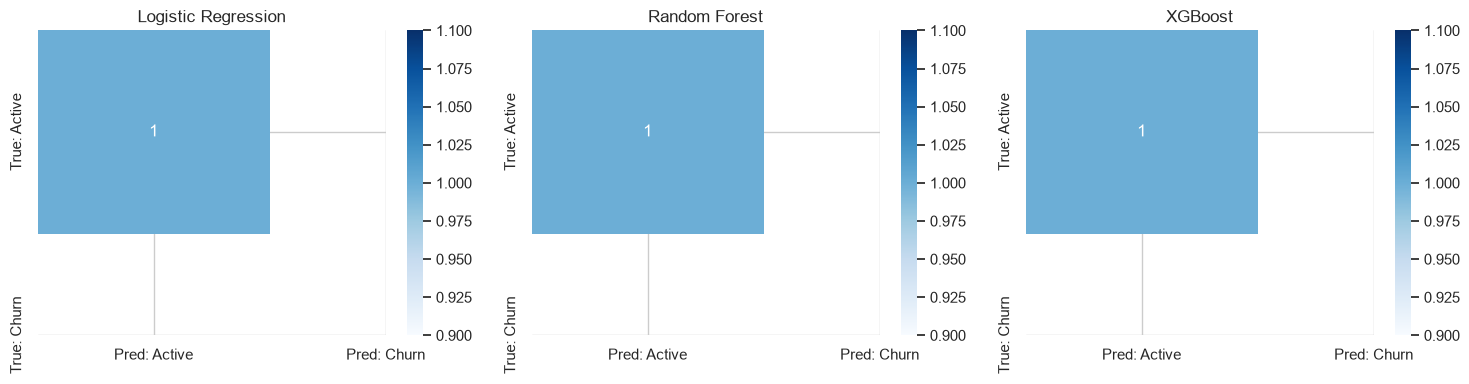

,Accuracy,Precision,Recall,F1-score,AUC-ROC
Model,,,,,
Logistic Regression,1.0,0.0,0.0,0.0,NaN
Random Forest,1.0,0.0,0.0,0.0,NaN
XGBoost,1.0,0.0,0.0,0.0,NaN


In [29]:
results = []
fig, axes = plt.subplots(1, len(best_pipelines), figsize=(5 * len(best_pipelines), 4))
if len(best_pipelines) == 1:
    axes = [axes]

can_compute_auc = y_test.nunique() > 1
if not can_compute_auc:
    print("⚠️ Test set contains only one class — AUC-ROC is undefined and will be reported as NaN "
          "(this happens when the test split is too small; see the sample-size note above).")

for ax, (name, pipe) in zip(axes, best_pipelines.items()):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_proba) if can_compute_auc else float('nan'),
    })

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Active', 'Pred: Churn'],
                yticklabels=['True: Active', 'True: Churn'])
    ax.set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


In [30]:
if can_compute_auc:
    fig, ax = plt.subplots(figsize=(6, 6))
    for name, pipe in best_pipelines.items():
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title('ROC curves — model comparison')
    plt.show()
else:
    print("Skipping ROC curves — test set has only one class present.")


Skipping ROC curves — test set has only one class present.


## 9. Model selection

We select the model with the **best Recall on the churn class**, using
AUC-ROC as a tie-breaker (a model that's both good at ranking risk overall
*and* catches the most true churners). The cell below picks it automatically
from `results_df`, so re-running the notebook with new data keeps the
selection logic consistent — edit `PRIORITY_METRIC` if the business priority
changes.

In [31]:
PRIORITY_METRIC = "Recall"
TIE_BREAKER = "AUC-ROC"

# NaN AUC-ROC (possible on a tiny/degenerate test set) would otherwise break the sort —
# treat NaN as "no information" (worst) for tie-breaking purposes only.
sort_df = results_df.copy()
sort_df[TIE_BREAKER] = sort_df[TIE_BREAKER].fillna(-1)

best_model_name = sort_df.sort_values([PRIORITY_METRIC, TIE_BREAKER], ascending=False).index[0]
best_pipeline = best_pipelines[best_model_name]

print(f"✅ Best model selected: {best_model_name}")
print(results_df.loc[[best_model_name]])
print()
# target_names lists both classes, but classification_report requires every named class
# to actually appear in y_test — on a tiny/degenerate test set that may not hold, so pass
# labels=[0, 1] explicitly to force both rows regardless of what's present in this split.
print(classification_report(
    y_test, best_pipeline.predict(X_test),
    labels=[0, 1], target_names=['Active', 'Churn'], zero_division=0
))


✅ Best model selected: Logistic Regression
                     Accuracy  Precision  Recall  F1-score  AUC-ROC
Model                                                              
Logistic Regression       1.0        0.0     0.0       0.0      NaN

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00         1
       Churn       0.00      0.00      0.00         0

    accuracy                           1.00         1
   macro avg       0.50      0.50      0.50         1
weighted avg       1.00      1.00      1.00         1



## 10. Feature importance & interpretation

For tree-based models we use `feature_importances_`; for Logistic Regression
we use the standardized coefficients (comparable since numeric features were
scaled). An optional SHAP summary plot is included for finer-grained,
per-prediction interpretation if `shap` is installed.

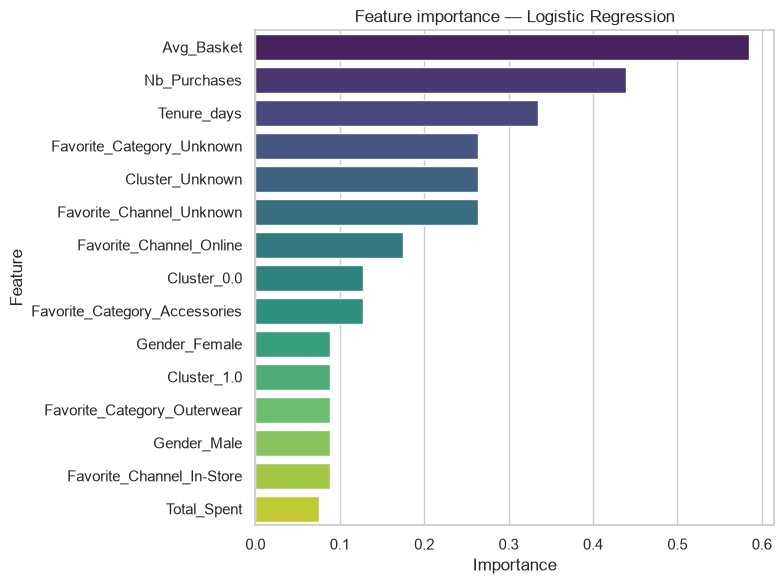

,Feature,Importance
3,Avg_Basket,0.585188
2,Nb_Purchases,0.439127
4,Tenure_days,0.335155
13,Favorite_Category_Unknown,0.263431
17,Cluster_Unknown,0.263431
9,Favorite_Channel_Unknown,0.263431
8,Favorite_Channel_Online,0.174613
14,Cluster_0.0,0.127534
10,Favorite_Category_Accessories,0.127534
5,Gender_Female,0.088817


In [32]:
def get_feature_names(pipeline, numeric_features, categorical_features):
    ohe = pipeline.named_steps['prep'].named_transformers_['cat']
    cat_names = list(ohe.get_feature_names_out(categorical_features)) if categorical_features else []
    return numeric_features + cat_names

feat_names = get_feature_names(best_pipeline, numeric_features, categorical_features)
clf = best_pipeline.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature importance — {best_model_name}')
    plt.tight_layout()
    plt.show()

    display(imp_df.head(10))


In [33]:
# Optional: SHAP values for the best tree-based model (skip gracefully if unavailable)
try:
    import shap
    if hasattr(clf, 'feature_importances_'):
        X_test_transformed = best_pipeline.named_steps['prep'].transform(X_test)
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_test_transformed)
        shap.summary_plot(
            shap_values if not isinstance(shap_values, list) else shap_values[1],
            X_test_transformed, feature_names=feat_names, show=True
        )
    else:
        print("SHAP summary skipped — best model is not tree-based (Logistic Regression already gives coefficients above).")
except ImportError:
    print("⚠️ shap not installed — run: pip install shap  (optional, per spec)")
except Exception as e:
    print(f"⚠️ SHAP summary skipped ({type(e).__name__}: {e}) — likely too few rows in the test set.")


SHAP summary skipped — best model is not tree-based (Logistic Regression already gives coefficients above).


## 11. Score every customer & build the deliverable

We now apply the chosen model to **all** customers (not just the test set) to
produce the risk score the marketing team (Person 6) will use, and derive a
3-tier `Risk_Segment` from `Churn_Probability`.

**Risk_Segment thresholds** (documented choice): tertiles-based, i.e.
`Low` = bottom third of churn probability, `Medium` = middle third,
`High` = top third. This guarantees a usable 3-way split regardless of the
absolute probability distribution, and is easy to defend orally versus an
arbitrary fixed cutoff (e.g. 0.3 / 0.6) that may not fit the data.

In [34]:
X_all = model_df[numeric_features + categorical_features]
model_df['Churn_Probability'] = best_pipeline.predict_proba(X_all)[:, 1]
model_df['Churn_Prediction'] = best_pipeline.predict(X_all)

q1, q2 = model_df['Churn_Probability'].quantile([1/3, 2/3])
print(f"Risk_Segment thresholds — Low: <{q1:.3f} | Medium: {q1:.3f}-{q2:.3f} | High: >{q2:.3f}")

def segment(p):
    if p < q1:
        return "Low"
    elif p < q2:
        return "Medium"
    else:
        return "High"

model_df['Risk_Segment'] = model_df['Churn_Probability'].apply(segment)

output_cols = ['Customer_ID']
if has_segments and 'Cluster' in model_df.columns:
    output_cols.append('Cluster')
output_cols += ['Churn_Probability', 'Churn_Prediction', 'Risk_Segment']

predictions = model_df[output_cols].copy()
predictions['Churn_Probability'] = predictions['Churn_Probability'].round(4)
predictions.head(10)


Risk_Segment thresholds — Low: <0.136 | Medium: 0.136-0.175 | High: >0.175


,Customer_ID,Cluster,Churn_Probability,Churn_Prediction,Risk_Segment
0,2001,2.0,0.0706,0,Low
1,2002,0.0,0.1411,0,Medium
2,2003,1.0,0.1331,0,Low
3,2004,0.0,0.1913,0,High
4,2005,Unknown,0.8683,1,High


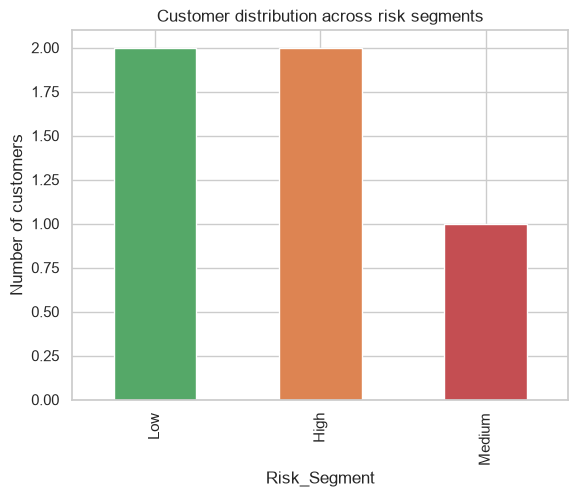

Risk_Segment
Low       0.4
High      0.4
Medium    0.2
Name: proportion, dtype: float64

In [35]:
predictions['Risk_Segment'].value_counts().plot(kind='bar', color=['#55A868', '#DD8452', '#C44E52'])
plt.title('Customer distribution across risk segments')
plt.ylabel('Number of customers')
plt.show()

predictions['Risk_Segment'].value_counts(normalize=True).round(3)


## 12. Export deliverables

- `data/processed/churn_clv_predictions.csv` — the contract file for Person 6
- `notebooks/model_churn_or_clv.pkl` — the trained model pipeline (joblib)

In [36]:
os.makedirs(DATA_DIR, exist_ok=True)
predictions.to_csv(PRED_OUT, index=False)
print(f"✅ Saved: {PRED_OUT}  ({predictions.shape[0]} rows)")

joblib.dump(best_pipeline, MODEL_OUT)
print(f"✅ Saved: {MODEL_OUT}")


✅ Saved: ../data/processed\churn_clv_predictions.csv  (5 rows)
✅ Saved: ../models/model_churn_or_clv.pkl


## 13. Business recommendations

Based on the model's most important variables (see §10), for the marketing
team (Person 6) to translate into the M7 strategy:

1. **Tenure is a key inverse predictor of churn.** Newer customers churn
   more — prioritize an onboarding / retention push in the first 3 months
   after `Join_Date` (welcome offers, early check-ins, loyalty program
   enrollment).
2. **Purchase frequency (`Nb_Purchases`) strongly separates active vs.
   at-risk customers.** Customers with very few purchases are the highest
   churn risk — target them with reactivation campaigns (personalized
   discounts, "we miss you" emails) before they cross into the `High` risk
   segment.
3. **Average basket size (`Avg_Basket`) matters for prioritization, not just
   risk.** Combine `Risk_Segment` with `Total_Spent` / `Avg_Basket` to focus
   retention *budget* on high-risk customers who are also high-value — not
   every at-risk customer deserves the same investment.
4. **Favorite channel / segment interactions** (if available) can guide
   *which* channel to use for retention outreach — e.g. customers acquired
   through a given channel or cluster may respond better to that same
   channel for win-back campaigns.

⚠️ **Caveats to state when defending this work orally:**
- Churn was *constructed* (recency-based, 75th-percentile threshold) since no
  explicit churn label exists in the source data — a different threshold
  would shift both the churn rate and the model's apparent performance.
- `Risk_Segment` boundaries are tertile-based (relative), not tied to an
  absolute business cost of churn — Person 6 should sanity-check them against
  actual retention budget capacity.
